## Synthetic Fluid Generation

This notebook contains the synthetic fluid generation workflow used in the study. Since the initial fluids were generated through randomized sampling within literature-based bounds, rerunning the sampling cells without fixing the original random state would produce a different initial set. For reproducibility of the published workflow, the notebook is shared in its original executed state.

In [6]:
import importlib
import Functions_PumpAI as fun
importlib.reload(fun)

XGBoost version: 3.2.0


<module 'Functions_PumpAI' from '/Users/danielmorantes/PythonP/ua_alframework_pump/Functions_PumpAI.py'>

**NEWTONIAN FLUIDS**

In [14]:
#Define the operative ranges 
OpRan_SFN = {
    'Rho(kg/mˆ3)': [762, 997],
    'K (Pa*sˆn)': [0.001, 0.069]}

#Define the number of fluids to generate
Num_fluids = 6

#Generate the synthetic fluids
fun.generate_sinthetic_fluids(OpRan_SFN, Num_fluids,"SFN")

Data saved as SFN.xlsx


,Rho(kg/mˆ3),K (Pa*sˆn)
0,839.829761,0.031543
1,933.921597,0.030300
2,860.877412,0.038046
3,885.298499,0.041453
4,888.561966,0.045680
5,961.380823,0.018756


**FLUIDS MODELED BY POWER LAW**

In [3]:
#Define the operative ranges 
OpRan_SFPL = {'Concentration': [0.0001, 0.0320],
    'Rho(kg/mˆ3)': [997, 1018],
    'K (Pa*sˆn)': [0.00115, 15.310],
    'n (-)': [0.15, 0.955]
    }

#Define the number of fluids to generate
Num_fluids = 10

#Generate the synthetic fluids
fun.generate_sinthetic_fluids(OpRan_SFPL, Num_fluids, "SFPL")

Data saved as SFPL.xlsx


,Concentration,Rho(kg/mˆ3),K (Pa*sˆn),n (-)
0,0.031550,1014.152259,6.807716,0.430465
1,0.001734,1017.862934,10.823221,0.334540
2,0.023371,1006.227081,1.261718,0.440647
3,0.013376,1003.081454,2.139699,0.305698
4,0.000184,997.116688,9.296098,0.605161
5,0.029575,1014.660341,15.274410,0.201703
6,0.017106,1008.485299,9.911015,0.440112
7,0.022353,1017.243594,6.402060,0.652328
8,0.007896,1011.930610,0.353767,0.460036
9,0.001261,1002.141349,0.615905,0.572275


**FLUIDS MODELED BY CROSS-FLUID**

In [2]:
#Define the operative ranges 
OpRan_SFCF = {'Concentration': [0.005, 0.0250],
    'Rho(kg/mˆ3)': [1010, 1020],
    'Miuinf (Pa*s)': [0, 0.011],
    'Miu0 (Pa*s)': [0.559, 37,700],
    'GammaC (1/s)': [0.935, 22.272],
    'm (-)': [0.704, 0.719]
    }

#Define the number of fluids to generate
Num_fluids = 10

#Generate the synthetic fluids
fun.generate_sinthetic_fluids(OpRan_SFCF, Num_fluids, "SFCF")

Data saved as SFCF.xlsx


,Concentration,Rho(kg/mˆ3),Miuinf (Pa*s),Miu0 (Pa*s),GammaC (1/s),m (-)
0,0.019963,1019.053269,0.010211,31.425603,2.507283,0.711067
1,0.005667,1014.780719,0.007078,3.972715,22.147291,0.704755
2,0.008531,1016.564309,0.003951,26.099338,4.507738,0.710042
3,0.010045,1016.660200,0.009743,6.360025,11.286461,0.707149
4,0.005471,1011.263806,0.001936,34.449965,15.694848,0.712509
5,0.018096,1019.858139,0.003887,27.113299,18.659299,0.706910
6,0.011551,1011.948893,0.003290,29.804380,21.453416,0.712898
7,0.006685,1019.898314,0.003684,28.489496,18.266085,0.710944
8,0.011204,1018.989242,0.004789,15.140989,16.478604,0.707830
9,0.020672,1012.670926,0.000302,19.606564,10.348328,0.713715


**FITTING CROSS MODEL TO POWER LAW**

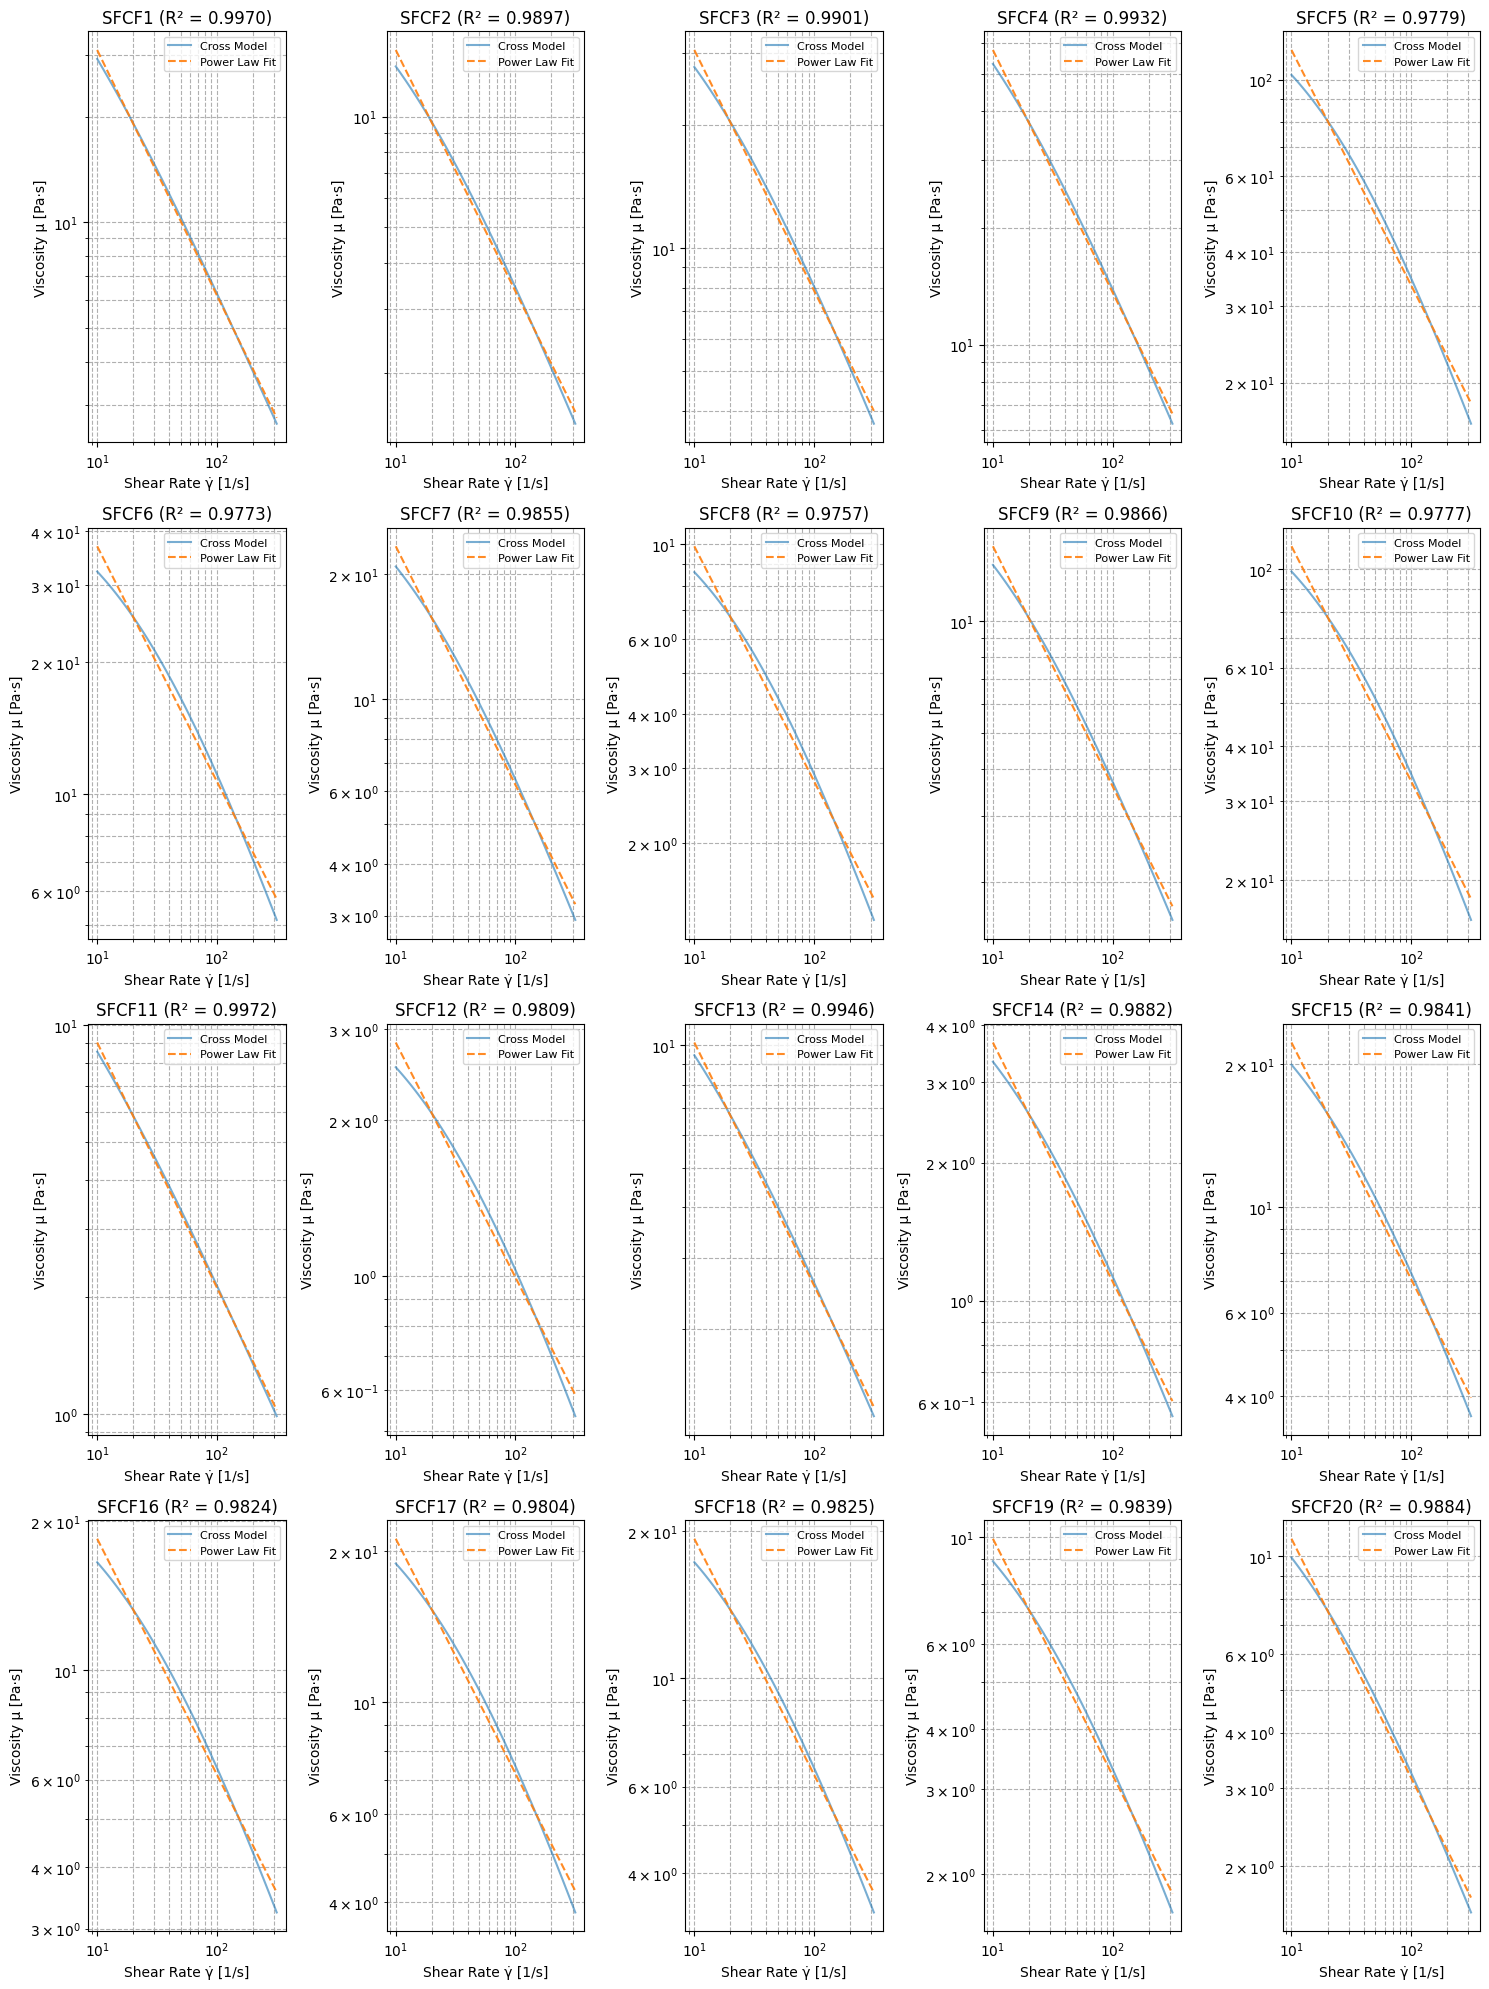

   Fluid_ID    Fitted_K  Fitted_n        R2
0     SFCF1  155.027051  0.300570  0.997045
1     SFCF2   69.065420  0.342376  0.989738
2     SFCF3  117.833406  0.412139  0.990058
3     SFCF4  242.903441  0.374444  0.993169
4     SFCF5  408.734988  0.456939  0.977890
5     SFCF6  127.184622  0.462010  0.977309
6     SFCF7   88.065227  0.423974  0.985534
7     SFCF8   35.022311  0.450700  0.975722
8     SFCF9   69.806293  0.356379  0.986649
9    SFCF10  379.359176  0.471662  0.977667
10   SFCF11   38.611731  0.369326  0.997198
11   SFCF12    8.044148  0.545655  0.980935
12   SFCF13   40.335556  0.401392  0.994599
13   SFCF14   12.161416  0.478198  0.988216
14   SFCF15   70.147342  0.501072  0.984110
15   SFCF16   55.141226  0.523483  0.982434
16   SFCF17   61.865991  0.533324  0.980411
17   SFCF18   58.434034  0.517966  0.982466
18   SFCF19   30.571470  0.510442  0.983856
19   SFCF20   37.903992  0.460455  0.988356


In [ ]:
file_path = "artifacts/fittings.xlsx" #replace with the actual path to the file with the fittings
sheet_name = "FittingCF_PL"

df_full, df_cross_fits = fun.fit_all_cross_fluids_to_powerlaw(
    file_path, sheet_name, header_row=0, plot=True)

print(df_cross_fits)
df_cross_fits.to_excel("fittings.xlsx", index=False)